In [1]:
# =============================================================
# CELDA 1: Verificación de Entorno y GPU
# =============================================================
import sys
import os
import platform
import tensorflow as tf
import numpy as np

print(f"Python: {sys.version}")
print(f"Plataforma: {platform.platform()}")
print(f"TensorFlow: {tf.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Compilado con CUDA?: {tf.test.is_built_with_cuda()}")

# Habilitar 'memory growth' para evitar que TF reserve toda la VRAM
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPUs Físicas detectadas: {gpus}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(f"GPUs Lógicas: {logical_gpus}")
        print("\n✅ TensorFlow está listo para usar la GPU.")
    except Exception as e:
        print(f"No se pudo activar 'memory growth': {e}")
else:
    print("\n⚙️ No se detectaron GPUs. TensorFlow usará la CPU.")

2026-08-02 19:55:29.512236: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-08-02 19:55:30.314411: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Python: 3.11.11 (main, Aug  2 2026, 18:59:03) [GCC 13.3.0]
Plataforma: Linux-6.17.0-14-generic-x86_64-with-glibc2.39
TensorFlow: 2.16.1
NumPy: 1.26.4
Compilado con CUDA?: True
GPUs Físicas detectadas: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPUs Lógicas: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]

✅ TensorFlow está listo para usar la GPU.


2026-08-02 19:55:31.935788: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-02 19:55:31.966139: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-08-02 19:55:31.967490: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [2]:
# =============================================================
# CELDA 2: Importar todas las librerías
# =============================================================
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import cv2  # Usaremos OpenCV para cargar y redimensionar (más robusto)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, LeakyReLU
from tensorflow.keras.optimizers import Adagrad  # Importamos el optimizador
from tensorflow.keras.callbacks import CSVLogger

%matplotlib inline

In [3]:
# =============================================================
# CELDA 2: Importar todas las librerías
# =============================================================
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import cv2  # Usaremos OpenCV para cargar y redimensionar (más robusto)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, LeakyReLU
from tensorflow.keras.optimizers import Adagrad  # Importamos el optimizador
from tensorflow.keras.callbacks import CSVLogger

%matplotlib inline

In [4]:
# =============================================================
# CELDA 3: Cargar y Redimensionar Imágenes
# =============================================================
# La forma correcta es redimensionar las imágenes AHORA,
# no después, o np.array() fallará.

dirname = os.path.join(os.getcwd(), 'sportimages')
imgpath = dirname + os.sep 

# Dimensiones que espera el modelo (alto, ancho)
IMG_HEIGHT = 21
IMG_WIDTH = 28

images = []
labels = []
directories = []
dircount = []
prevRoot = ''
cant = 0

print(f"Leyendo imagenes de {imgpath}...")

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search(r"\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant += 1
            filepath = os.path.join(root, filename)
            
            # Cargar imagen con OpenCV
            image = cv2.imread(filepath)
            if image is None:
                print(f"Omitiendo imagen corrupta o no válida: {filename}")
                continue
                
            # Convertir de BGR (OpenCV) a RGB (Matplotlib/Keras)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            
            # Redimensionar a (ancho, alto) para cv2.resize
            image_resized = cv2.resize(image_rgb, (IMG_WIDTH, IMG_HEIGHT))
            
            images.append(image_resized)
            labels.append(root) # Guardamos el path para sacar la etiqueta luego

            b = "Leyendo..." + str(cant)
            print(b, end="\r")

            if prevRoot != root:
                prevRoot = root
                directories.append(root)
                dircount.append(cant)
                cant = 0

dircount.append(cant)
dircount = dircount[1:]
# dircount[0] = dircount[0] + 1 # Esta línea parecía un error, la comento

print('\nDirectorios leídos:', len(directories))
print("Imagenes en cada directorio:", dircount)
print('Suma Total de imagenes en subdirs:', sum(dircount))

Leyendo imagenes de /home/judamo/Projects/Big-Data/Lab-1/sportimages/...
Leyendo...9767
Directorios leídos: 10
Imagenes en cada directorio: [7533, 8823, 5172, 7752, 5053, 9348, 7125, 8937, 7617, 9767]
Suma Total de imagenes en subdirs: 77127


In [5]:
# =============================================================
# CELDA 4: Crear Etiquetas
# =============================================================

# Crear lista de nombres de clases (deportes)
deportes = [d.split(os.sep)[-1] for d in directories]
print(f"Clases: {deportes}")

# Mapear los nombres de directorio (labels) a índices numéricos
label_map = {name: i for i, name in enumerate(directories)}
y_labels = [label_map[label] for label in labels]

# Convertir listas a Arrays de NumPy
X = np.array(images, dtype=np.uint8)
y = np.array(y_labels)

nClasses = len(deportes)
print(f'\nTotal de salidas (clases): {nClasses}')
print(f'Shape de X (imágenes): {X.shape}')
print(f'Shape de y (etiquetas): {y.shape}')

Clases: ['ciclismo', 'basket', 'natacion', 'beisball', 'f1', 'americano', 'boxeo', 'tenis', 'futbol', 'golf']

Total de salidas (clases): 10
Shape de X (imágenes): (77128, 21, 28, 3)
Shape de y (etiquetas): (77128,)


In [6]:
# =============================================================
# CELDA 5: Crear Sets de Entrenamiento y Test
# =============================================================
train_X, test_X, train_Y, test_Y = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print('Datos de Entrenamiento (Train):', train_X.shape, train_Y.shape)
print('Datos de Prueba (Test):', test_X.shape, test_Y.shape)

Datos de Entrenamiento (Train): (61702, 21, 28, 3) (61702,)
Datos de Prueba (Test): (15426, 21, 28, 3) (15426,)


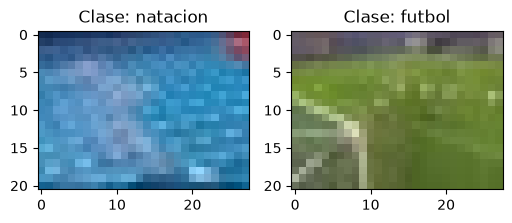

In [7]:
# =============================================================
# CELDA 6: Visualizar Muestras
# =============================================================
plt.figure(figsize=[6, 3])

# Imagen de Entrenamiento
plt.subplot(121)
plt.imshow(train_X[0]) # Quitado cmap='gray', las imágenes son RGB
plt.title(f"Clase: {deportes[train_Y[0]]}")

# Imagen de Prueba
plt.subplot(122)
plt.imshow(test_X[0]) # Quitado cmap='gray'
plt.title(f"Clase: {deportes[test_Y[0]]}")
plt.show()

In [8]:
# =============================================================
# CELDA 7: Preprocesamiento Final
# =============================================================

# 1. Normalizar píxeles a [0, 1]
train_X = train_X.astype('float32') / 255.
test_X = test_X.astype('float32') / 255.

# 2. Convertir etiquetas a One-Hot Encoding
train_Y_one_hot = to_categorical(train_Y, nClasses)
test_Y_one_hot = to_categorical(test_Y, nClasses)

print('Etiqueta original:', train_Y[0])
print('Etiqueta One-Hot:', train_Y_one_hot[0])

# 3. Crear set de Validación (a partir del set de entrenamiento)
train_X, valid_X, train_label, valid_label = train_test_split(
    train_X, 
    train_Y_one_hot, 
    test_size=0.2, 
    random_state=13,
    stratify=np.argmax(train_Y_one_hot, axis=1) # Estratificar en validación también
)

print(f"\nShape Final de Train: {train_X.shape}, {train_label.shape}")
print(f"Shape Final de Valid: {valid_X.shape}, {valid_label.shape}")
print(f"Shape Final de Test: {test_X.shape}, {test_Y_one_hot.shape}")

Etiqueta original: 2
Etiqueta One-Hot: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]

Shape Final de Train: (49361, 21, 28, 3), (49361, 10)
Shape Final de Valid: (12341, 21, 28, 3), (12341, 10)
Shape Final de Test: (15426, 21, 28, 3), (15426, 10)


In [9]:
# =============================================================
# CELDA 8: Construir el modelo CNN
# =============================================================

# Parámetros
INIT_LR = 1e-3
epochs = 10
batch_size = 64
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3) # (21, 28, 3)

sport_model = Sequential()
sport_model.add(Conv2D(32, kernel_size=(3, 3), activation='linear', padding='same', input_shape=input_shape))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(MaxPooling2D((2, 2), padding='same'))
sport_model.add(Dropout(0.5))

sport_model.add(Flatten())
sport_model.add(Dense(32, activation='linear'))
sport_model.add(LeakyReLU(alpha=0.1))
sport_model.add(Dropout(0.5))

sport_model.add(Dense(nClasses, activation='softmax'))

# =============================================================
# CELDA 9: Compilar el Modelo
# =============================================================

# Corregido el optimizador: tf.keras.optimizers.Adagrad
# 'decay' está obsoleto, pero se mantiene si usas TF 2.10
optimizer = Adagrad(learning_rate=INIT_LR, decay=INIT_LR / 100)

sport_model.compile(
    loss='categorical_crossentropy', 
    optimizer=optimizer, 
    metrics=['accuracy']
)

sport_model.summary()

/home/judamo/Projects/Big-Data/Lab-1/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/judamo/Projects/Big-Data/Lab-1/.venv/lib/python3.11/site-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(
/home/judamo/Projects/Big-Data/Lab-1/.venv/lib/python3.11/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 21, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 21, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       157,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,954 (620.91 KB)

 Trainable params: 158,954 (620.91 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# =============================================================
# CELDA 10: Entrenar
# =============================================================

# Callback para guardar el historial en un CSV
csv_logger = CSVLogger("history_log.csv", separator=",", append=False)

print("Iniciando entrenamiento...")
# Este paso puede tardar varios minutos
sport_train = sport_model.fit(
    train_X, train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label),
    callbacks=[csv_logger]
)

print("Entrenamiento finalizado.")

Iniciando entrenamiento...
Epoch 1/10


2026-08-02 19:57:48.754442: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 348291216 exceeds 10% of free system memory.
2026-08-02 19:57:49.076320: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 348291216 exceeds 10% of free system memory.
I0000 00:00:1785718669.691967   66642 service.cc:145] XLA service 0x71ca84009050 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785718669.692016   66642 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 2060, Compute Capability 7.5
2026-08-02 19:57:49.717186: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-08-02 19:57:49.767324: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:465] Loaded cuDNN version 8907


 99/772 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1259 - loss: 2.2981

I0000 00:00:1785718671.533155   66642 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


772/772 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.2232 - loss: 2.1251 - val_accuracy: 0.4692 - val_loss: 1.8149
Epoch 2/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3549 - loss: 1.8081 - val_accuracy: 0.5830 - val_loss: 1.5222
Epoch 3/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4322 - loss: 1.6166 - val_accuracy: 0.6224 - val_loss: 1.3386
Epoch 4/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4910 - loss: 1.4744 - val_accuracy: 0.6639 - val_loss: 1.1957
Epoch 5/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5308 - loss: 1.3687 - val_accuracy: 0.7078 - val_loss: 1.0903
Epoch 6/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5629 - loss: 1.2864 - val_accuracy: 0.7274 - val_loss: 1.0137
Epoch 7/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5814 - loss: 1.2267 - val_accuracy: 0.7531 - val_loss: 0.9563
Epoch 8/10
772/772 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6052 - loss: 1.1705 - val_accuracy: 0.7680 - val_

In [11]:
# =============================================================
# CELDA 11: Guardar y Cargar el Modelo
# =============================================================

# Guardar el modelo entrenado en formato HDF5
sport_model.save("sports_cnn_model.h5")
print("Modelo guardado en 'sports_cnn_model.h5'")

# Cargarlo de nuevo (como prueba)
try:
    loaded_model = tf.keras.models.load_model("sports_cnn_model.h5")
    print("\nModelo cargado exitosamente.")
    loaded_model.summary()
except Exception as e:
    print(f"\nError al cargar el modelo: {e}")

Modelo guardado en 'sports_cnn_model.h5'

Modelo cargado exitosamente.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 21, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 21, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       157,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,956 (620.93 KB)

 Trainable params: 158,954 (620.91 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [12]:
# =============================================================
# CELDA 12: Evaluar en el Set de Prueba (Test)
# =============================================================

print("Evaluando el modelo con el set de prueba...")
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

print(f'\nTest Loss (Pérdida): {test_eval[0]:.4f}')
print(f'Test Accuracy (Precisión): {test_eval[1] * 100:.2f}%')

Evaluando el modelo con el set de prueba...
483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7887 - loss: 0.8349

Test Loss (Pérdida): 0.8349
Test Accuracy (Precisión): 78.87%


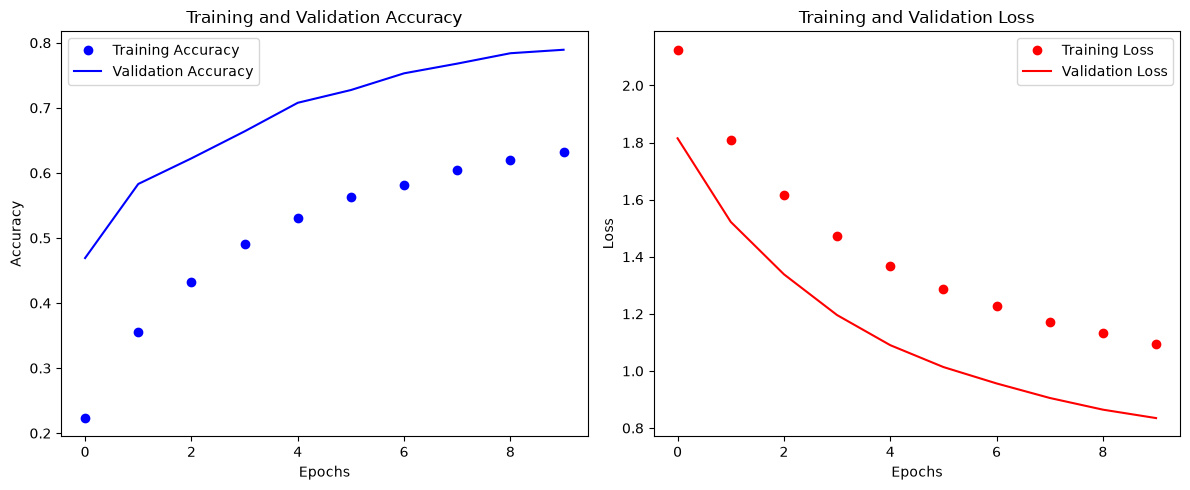

In [15]:
# =============================================================
# CELDA 13: Graficar historial de entrenamiento
# =============================================================

# Extraer historial del objeto 'sport_train.history'
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']
epochs_range = range(len(accuracy))

# Gráfica de Precisión (Accuracy)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, accuracy, 'bo', label='Training Accuracy')
plt.plot(epochs_range, val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, 'ro', label='Training Loss')
plt.plot(epochs_range, val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [16]:
# =============================================================
# CELDA 14: Reporte de Clasificación detallado
# =============================================================

# Predecir las clases en el set de prueba
predicted_probabilities = sport_model.predict(test_X)

# Convertir probabilidades a la clase con mayor probabilidad (índice)
predicted_classes = np.argmax(predicted_probabilities, axis=1)

print("--- Reporte de Clasificación ---\n")
# Comparamos las clases predichas (predicted_classes) con las etiquetas reales (test_Y)
# Usamos la lista 'deportes' para los nombres de las clases
print(classification_report(test_Y, predicted_classes, target_names=deportes))

483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
--- Reporte de Clasificación ---

              precision    recall  f1-score   support

    ciclismo       0.94      0.99      0.96      1507
      basket       0.74      0.85      0.79      1765
    natacion       0.92      0.93      0.92      1034
    beisball       0.83      0.67      0.74      1550
          f1       0.70      0.35      0.46      1011
   americano       0.62      0.48      0.54      1870
       boxeo       0.85      0.88      0.86      1425
       tenis       0.93      1.00      0.96      1787
      futbol       0.94      0.75      0.83      1523
        golf       0.60      0.89      0.71      1954

    accuracy                           0.79     15426
   macro avg       0.81      0.78      0.78     15426
weighted avg       0.80      0.79      0.78     15426



Total Aciertos: 12166
Total Errores: 3260

--- Muestras de Aciertos ---


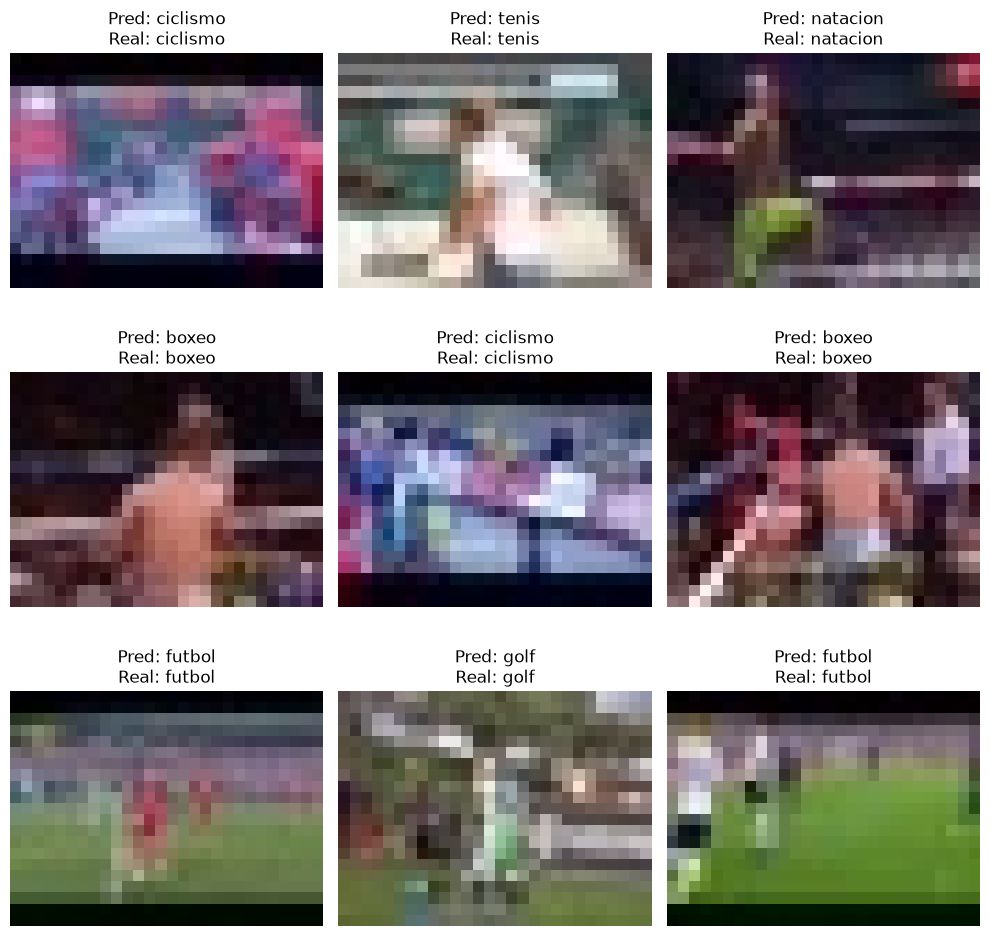


--- Muestras de Errores ---


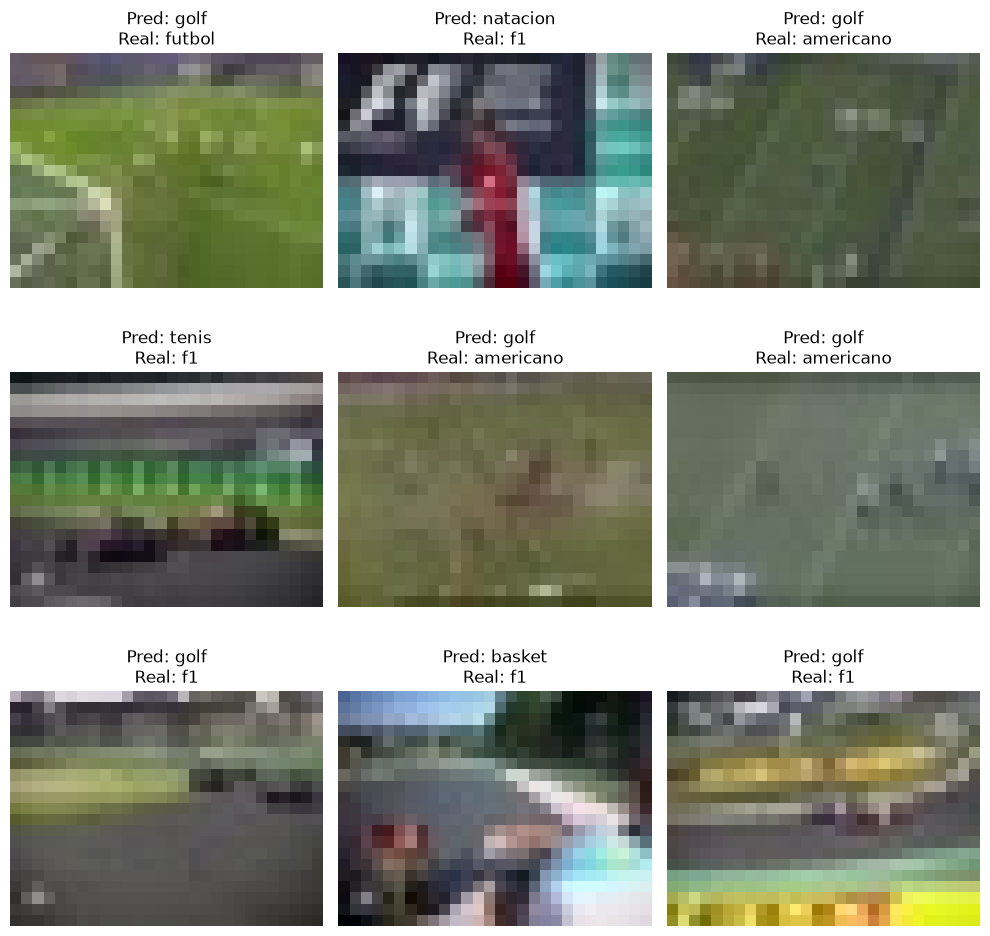

In [17]:
# =============================================================
# CELDA 15: Visualizar Aciertos y Errores
# =============================================================

# Corregido: Quitado .reshape() y cmap='gray'
# test_Y (reales) vs predicted_classes (predichas)

correct_indices = np.where(predicted_classes == test_Y)[0]
incorrect_indices = np.where(predicted_classes != test_Y)[0]

print(f"Total Aciertos: {len(correct_indices)}")
print(f"Total Errores: {len(incorrect_indices)}")

# Graficar 9 aciertos
print("\n--- Muestras de Aciertos ---")
plt.figure(figsize=(10, 10))
for i, correct in enumerate(correct_indices[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_X[correct])
    plt.title(f"Pred: {deportes[predicted_classes[correct]]}\nReal: {deportes[test_Y[correct]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

# Graficar 9 errores
print("\n--- Muestras de Errores ---")
plt.figure(figsize=(10, 10))
for i, incorrect in enumerate(incorrect_indices[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_X[incorrect])
    plt.title(f"Pred: {deportes[predicted_classes[incorrect]]}\nReal: {deportes[test_Y[incorrect]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [18]:
# =============================================================
# CELDA 16: Probar con una imagen nueva
# =============================================================

from skimage.transform import resize # El notebook original usaba esta

def predict_new_image(image_path):
    try:
        # Cargar imagen (usando plt.imread como en el código original de predicción)
        image = plt.imread(image_path)
        
        # Redimensionar (usando skimage.resize como en el código original)
        image_resized = resize(image, (IMG_HEIGHT, IMG_WIDTH), anti_aliasing=True)
        
        # Normalizar (si la imagen no está en 0-1)
        if image_resized.max() > 1.0:
            image_resized = image_resized / 255.0
            
        # Añadir dimensión de 'batch' (1, alto, ancho, canales)
        image_batch = np.expand_dims(image_resized, axis=0).astype('float32')

        # Realizar predicción
        prediction = sport_model.predict(image_batch)
        predicted_class_index = np.argmax(prediction)
        predicted_class_name = deportes[predicted_class_index]
        confidence = np.max(prediction) * 100

        print(f"Imagen: {image_path}")
        print(f"Predicción: {predicted_class_name} (Confianza: {confidence:.2f}%)")
        
        plt.imshow(image)
        plt.title(f"Pred: {predicted_class_name}")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"No se pudo procesar la imagen {image_path}: {e}")

# --- EJEMPLO DE CÓMO USARLA ---
# Cambia esta ruta a una imagen de prueba real en tu disco
# (La ruta original '../CLASIF_DEPORTES/test/deporte1.jpg' probablemente no exista)

# predict_new_image("ruta/a/mi/imagen_de_tenis.jpg")
# predict_new_image("ruta/a/mi/imagen_de_futbol.jpg")

In [20]:
# =============================================================
# CELDA 17: Importar Librerías para Métricas Detalladas
# =============================================================
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
from itertools import cycle
import numpy as np # Asegurarse que numpy está importado

print("Librerías para métricas cargadas.")

Librerías para métricas cargadas.


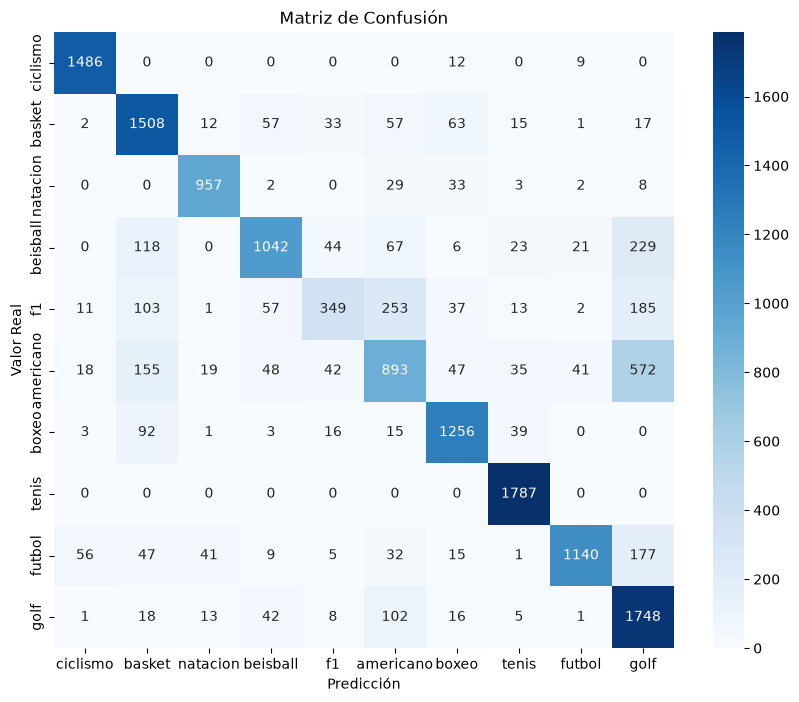

In [21]:
# =============================================================
# CELDA 18: Matriz de Confusión
# =============================================================

# Calcular la matriz de confusión
cm = confusion_matrix(test_Y, predicted_classes)

# Visualizar la matriz de confusión
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=deportes, yticklabels=deportes)
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

In [22]:
# =============================================================
# CELDA 19: Métricas Clave (Precisión, Recall, F1-Score)
# =============================================================

accuracy = accuracy_score(test_Y, predicted_classes)
# Usamos 'weighted' para promediar teniendo en cuenta el desbalance de clases
precision_w = precision_score(test_Y, predicted_classes, average='weighted')
recall_w = recall_score(test_Y, predicted_classes, average='weighted')
f1_w = f1_score(test_Y, predicted_classes, average='weighted')

# Usamos 'macro' para promediar sin tener en cuenta el desbalance
precision_m = precision_score(test_Y, predicted_classes, average='macro')
recall_m = recall_score(test_Y, predicted_classes, average='macro')
f1_m = f1_score(test_Y, predicted_classes, average='macro')

print(f"--- Métricas Generales ---")
print(f"Accuracy: {accuracy:.4f}")
print("\nPromedio Ponderado (Weighted):")
print(f"  Precision: {precision_w:.4f}")
print(f"  Recall:    {recall_w:.4f}")
print(f"  F1-Score:  {f1_w:.4f}")
print("\nPromedio Macro (Macro):")
print(f"  Precision: {precision_m:.4f}")
print(f"  Recall:    {recall_m:.4f}")
print(f"  F1-Score:  {f1_m:.4f}")

print("\n(Nota: El reporte de clasificación de la celda 14 ya muestra estas métricas por clase)")

--- Métricas Generales ---
Accuracy: 0.7887

Promedio Ponderado (Weighted):
  Precision: 0.7957
  Recall:    0.7887
  F1-Score:  0.7808

Promedio Macro (Macro):
  Precision: 0.8052
  Recall:    0.7785
  F1-Score:  0.7794

(Nota: El reporte de clasificación de la celda 14 ya muestra estas métricas por clase)


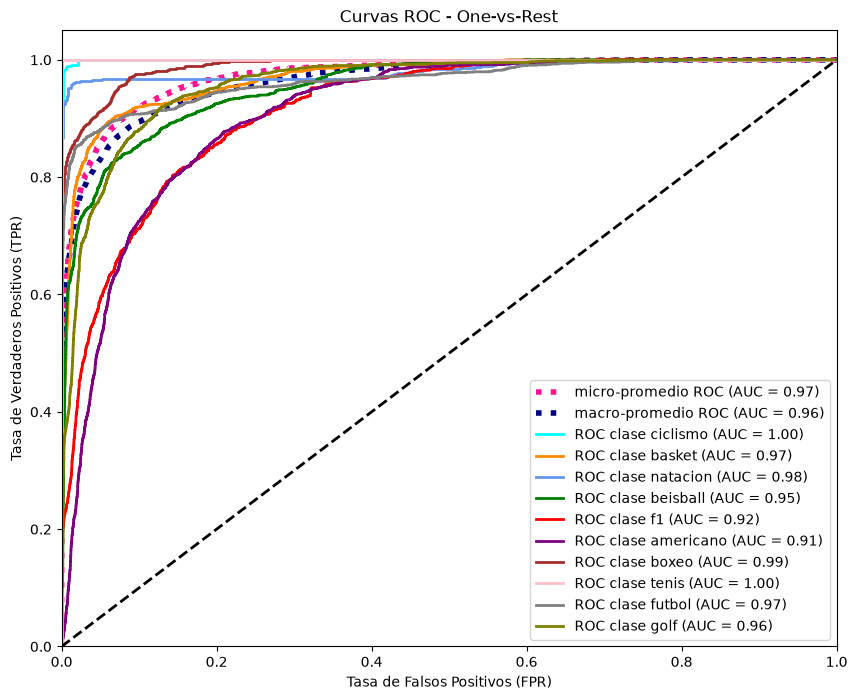

In [23]:
# =============================================================
# CELDA 20: Curvas ROC y Área Bajo la Curva (AUC) - One-vs-Rest
# =============================================================

# Binarizar las etiquetas reales (test_Y) para el enfoque OvR
y_test_bin = label_binarize(test_Y, classes=range(nClasses))

# Obtener las probabilidades predichas (ya las calculamos antes)
# predicted_probabilities tiene shape (n_samples, n_classes)

# Calcular ROC y AUC para cada clase
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(nClasses):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], predicted_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcular ROC y AUC micro-promedio
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), predicted_probabilities.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Calcular ROC y AUC macro-promedio
# Primero agregamos todas las tasas de falsos positivos
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(nClasses)]))
# Luego interpolamos todas las curvas ROC en estos puntos
mean_tpr = np.zeros_like(all_fpr)
for i in range(nClasses):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
# Promediamos y calculamos AUC
mean_tpr /= nClasses
fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Graficar todas las curvas ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr["micro"], tpr["micro"],
         label=f'micro-promedio ROC (AUC = {roc_auc["micro"]:.2f})',
         color='deeppink', linestyle=':', linewidth=4)

plt.plot(fpr["macro"], tpr["macro"],
         label=f'macro-promedio ROC (AUC = {roc_auc["macro"]:.2f})',
         color='navy', linestyle=':', linewidth=4)

colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown', 'pink', 'gray', 'olive'])
for i, color in zip(range(nClasses), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC clase {deportes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - One-vs-Rest')
plt.legend(loc="lower right")
plt.show()

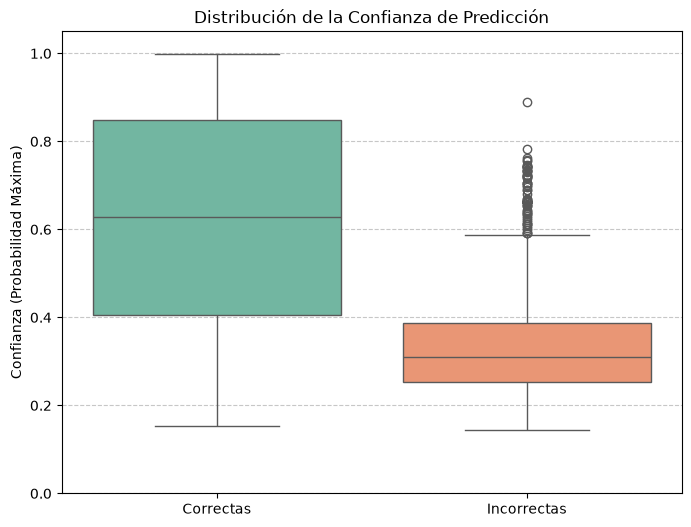

Confianza media (correctas): 0.627
Confianza media (incorrectas): 0.329


In [24]:
# =============================================================
# CELDA 21: Box Plot de Confianza de Predicción
# =============================================================
# Compara la probabilidad máxima predicha (confianza) para
# predicciones correctas vs. incorrectas

# Obtener la máxima probabilidad (confianza) para cada predicción
confidences = np.max(predicted_probabilities, axis=1)

# Separar confianzas de predicciones correctas e incorrectas
correct_confidences = confidences[correct_indices]
incorrect_confidences = confidences[incorrect_indices]

# Crear el box plot
plt.figure(figsize=(8, 6))
sns.boxplot(data=[correct_confidences, incorrect_confidences], palette="Set2")
plt.xticks([0, 1], ['Correctas', 'Incorrectas'])
plt.ylabel('Confianza (Probabilidad Máxima)')
plt.title('Distribución de la Confianza de Predicción')
plt.ylim(0, 1.05) # Asegura que el eje Y va de 0 a 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Confianza media (correctas): {np.mean(correct_confidences):.3f}")
print(f"Confianza media (incorrectas): {np.mean(incorrect_confidences):.3f}")

In [25]:
# =============================================================
# CELDA 22: Nota sobre Validación Cruzada
# =============================================================
# Este notebook usó una división simple: Entrenamiento / Validación / Prueba.
# La Validación Cruzada (Cross-Validation, CV) es una técnica más robusta
# que se usa DURANTE el entrenamiento para evaluar qué tan bien generalizará
# el modelo y para ajustar hiperparámetros.

# NO se aplica directamente al conjunto de PRUEBA (test_X) después de entrenar.
# El conjunto de prueba se reserva para una evaluación final única.

# Si quisieras usar CV (por ejemplo, K-Fold) para entrenar y evaluar:
# 1. NO dividirías X e y en train/test al principio (o lo harías después).
# 2. Usarías todo X (o la parte de entrenamiento) con KFold de scikit-learn.
# 3. En cada "fold", entrenarías el modelo en K-1 partes y validarías en la parte restante.
# 4. Promediarías las métricas de validación de todos los folds.
# 5. Finalmente, entrenarías el modelo definitivo con TODOS los datos (o la parte de entrenamiento)
#    y evaluarías UNA VEZ en el conjunto de prueba que reservaste.

# Ejemplo conceptual de estructura K-Fold (NO EJECUTAR AQUÍ):
# from sklearn.model_selection import StratifiedKFold
# n_splits = 5 # Por ejemplo, 5 folds
# skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
# fold_accuracies = []
# for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)): # Usando X e y originales
#     print(f"--- Fold {fold+1}/{n_splits} ---")
#     X_train_fold, X_val_fold = X[train_idx], X[val_idx]
#     y_train_fold, y_val_fold = y[train_idx], y[val_idx]
     # Preprocesar fold (normalizar, one-hot y_train_fold, y_val_fold)
     # Crear y compilar un NUEVO modelo (arquitectura idéntica)
     # model_fold = crear_modelo() # Función que define tu Sequential
     # model_fold.compile(...)
     # Entrenar en el fold
     # history_fold = model_fold.fit(X_train_fold_proc, y_train_fold_proc, ..., validation_data=(X_val_fold_proc, y_val_fold_proc))
     # Evaluar en la validación del fold
     # _, val_acc = model_fold.evaluate(X_val_fold_proc, y_val_fold_proc, verbose=0)
     # fold_accuracies.append(val_acc)
# print(f"\nAccuracy promedio en {n_splits}-Fold CV: {np.mean(fold_accuracies):.4f} +/- {np.std(fold_accuracies):.4f}")

print("Explicación sobre Validación Cruzada añadida.")

Explicación sobre Validación Cruzada añadida.


In [27]:
# =============================================================
# CELDA 11: Guardar y Cargar el Modelo Entrenado
# =============================================================
import tensorflow as tf
import os

# --- Opción 1: Formato HDF5 (Archivo único .h5) ---
hdf5_file_path = "sports_cnn_model.h5"
print(f"Guardando el modelo en formato HDF5 en: {hdf5_file_path}")
sport_model.save(hdf5_file_path) # 'sport_model' debe ser tu modelo Keras entrenado
print("Modelo guardado exitosamente en formato HDF5.")

# (Opcional) Cargar el modelo HDF5 para verificar
try:
    print(f"\nCargando modelo desde HDF5: {hdf5_file_path}")
    loaded_hdf5_model = tf.keras.models.load_model(hdf5_file_path)
    print("Modelo HDF5 cargado exitosamente.")
    # loaded_hdf5_model.summary() # Descomenta si quieres ver el resumen
except Exception as e:
    print(f"Error al cargar el modelo HDF5: {e}")


# --- Opción 2: Formato SavedModel (Carpeta) ---
saved_model_dir_path = "sports_cnn_savedmodel"
print(f"\nGuardando el modelo en formato SavedModel en la carpeta: {saved_model_dir_path}")
sport_model.export(saved_model_dir_path)# Guarda en una carpeta con ese nombre
print("Modelo guardado exitosamente en formato SavedModel.")

# (Opcional) Cargar el modelo SavedModel para verificar
try:
    print(f"\nCargando modelo desde SavedModel: {saved_model_dir_path}")
    loaded_savedmodel_model = tf.keras.models.load_model(saved_model_dir_path)
    print("Modelo SavedModel cargado exitosamente.")
    # loaded_savedmodel_model.summary() # Descomenta si quieres ver el resumen
except Exception as e:
    print(f"Error al cargar el modelo SavedModel: {e}")

Guardando el modelo en formato HDF5 en: sports_cnn_model.h5
Modelo guardado exitosamente en formato HDF5.

Cargando modelo desde HDF5: sports_cnn_model.h5
Modelo HDF5 cargado exitosamente.

Guardando el modelo en formato SavedModel en la carpeta: sports_cnn_savedmodel
INFO:tensorflow:Assets written to: sports_cnn_savedmodel/assets


INFO:tensorflow:Assets written to: sports_cnn_savedmodel/assets


Saved artifact at 'sports_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 21, 28, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  125118845882736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125118845884848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125118845890128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125118845891008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125118845890832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  125118845890656: TensorSpec(shape=(), dtype=tf.resource, name=None)
Modelo guardado exitosamente en formato SavedModel.

Cargando modelo desde SavedModel: sports_cnn_savedmodel
Error al cargar el modelo SavedModel: File format not supported: filepath=sports_cnn_savedmodel. Keras 3 only supports V3 `.keras` files, legacy H5 format files (`.h5` extension). Not

In [28]:
#-----------------------------------EXPLICACION DE MI MODELO-----------------------------------------------

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
Imagen: futbol_0985.jpg
Predicción: futbol
Confianza: 82.41%


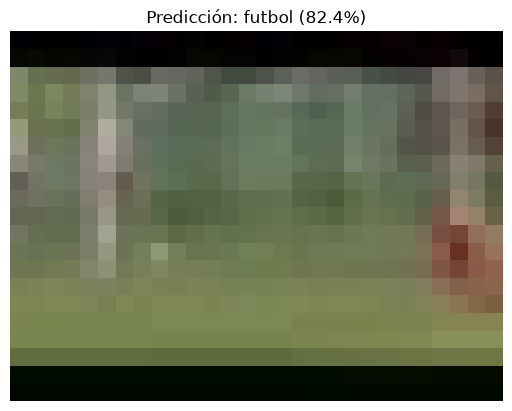

In [31]:
# =============================================================
# CELDA 16: Probar con una imagen nueva (Adaptada y mejorada)
# =============================================================
import cv2 # Asegúrate de que cv2 está importado
import numpy as np
import matplotlib.pyplot as plt

# Asegúrate de que IMG_HEIGHT, IMG_WIDTH, sport_model y deportes estén definidos
# por las celdas anteriores.
# IMG_HEIGHT = 21
# IMG_WIDTH = 28

def predict_single_image(image_path, model, target_height, target_width, class_names):
    """
    Carga, preprocesa y predice la clase de una única imagen.

    Args:
        image_path (str): Ruta al archivo de imagen.
        model (tf.keras.Model): El modelo Keras entrenado.
        target_height (int): Altura a la que redimensionar la imagen.
        target_width (int): Ancho al que redimensionar la imagen.
        class_names (list): Lista con los nombres de las clases (deportes).
    """
    try:
        # 1. Cargar imagen con OpenCV
        image_bgr = cv2.imread(image_path)
        if image_bgr is None:
            print(f"Error: No se pudo cargar la imagen en {image_path}")
            return

        # 2. Convertir de BGR a RGB
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        # 3. Redimensionar a las dimensiones esperadas por el modelo
        image_resized = cv2.resize(image_rgb, (target_width, target_height))

        # 4. Normalizar píxeles a [0, 1]
        image_normalized = image_resized.astype('float32') / 255.0

        # 5. Añadir dimensión de batch (1, height, width, channels)
        image_batch = np.expand_dims(image_normalized, axis=0)

        # 6. Realizar predicción
        predictions = model.predict(image_batch)
        predicted_class_index = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        predicted_class_name = class_names[predicted_class_index]

        # 7. Mostrar resultados
        print(f"Imagen: {os.path.basename(image_path)}")
        print(f"Predicción: {predicted_class_name}")
        print(f"Confianza: {confidence:.2f}%")

        plt.imshow(image_rgb) # Mostrar la imagen original (antes de redimensionar)
        plt.title(f"Predicción: {predicted_class_name} ({confidence:.1f}%)")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Ocurrió un error procesando {image_path}: {e}")

# --- EJEMPLO DE USO ---
# Reemplaza esta ruta con la ruta real a tu imagen de prueba
# Asegúrate que IMG_HEIGHT, IMG_WIDTH, sport_model, y deportes existen
image_to_test = 'sportimages/sportimages/futbol/futbol_0985.jpg' # Ajusta esta ruta!
#image_to_test = '../CLASIF_DEPORTES/test/deporte1.jpg' # Ajusta esta ruta!


if os.path.exists(image_to_test):
    predict_single_image(image_to_test, sport_model, IMG_HEIGHT, IMG_WIDTH, deportes)
else:
    print(f"Error: El archivo de prueba '{image_to_test}' no se encontró.")
    print("Por favor, verifica la ruta y el nombre del archivo.")

# Puedes llamar a la función de nuevo con otras imágenes:
# predict_single_image('../CLASIF_DEPORTES/test/otra_imagen.jpg', sport_model, IMG_HEIGHT, IMG_WIDTH, deportes)

In [30]:
# =============================================================
# CELDA 16: Probar con MÚLTIPLES imágenes nuevas
# =============================================================
import cv2 # Asegúrate de que cv2 está importado
import numpy as np
import matplotlib.pyplot as plt
import os # Necesario para os.path.basename y os.path.exists

# Asegúrate de que IMG_HEIGHT, IMG_WIDTH, sport_model y deportes estén definidos
# por las celdas anteriores.
# IMG_HEIGHT = 21
# IMG_WIDTH = 28

def predict_single_image(image_path, model, target_height, target_width, class_names):
    """
    Carga, preprocesa y predice la clase de una única imagen. Muestra la imagen y la predicción.

    Args:
        image_path (str): Ruta al archivo de imagen.
        model (tf.keras.Model): El modelo Keras entrenado.
        target_height (int): Altura a la que redimensionar la imagen.
        target_width (int): Ancho al que redimensionar la imagen.
        class_names (list): Lista con los nombres de las clases (deportes).
    """
    try:
        # 1. Cargar imagen con OpenCV
        image_bgr = cv2.imread(image_path)
        if image_bgr is None:
            print(f"--- Error al cargar {os.path.basename(image_path)} ---")
            print(f"Ruta completa: {image_path}")
            print("Verifica que la ruta y el nombre del archivo sean correctos.\n")
            return # Salta a la siguiente imagen si no se puede cargar

        # 2. Convertir de BGR a RGB
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        # 3. Redimensionar a las dimensiones esperadas por el modelo
        image_resized = cv2.resize(image_rgb, (target_width, target_height))

        # 4. Normalizar píxeles a [0, 1]
        image_normalized = image_resized.astype('float32') / 255.0

        # 5. Añadir dimensión de batch (1, height, width, channels)
        image_batch = np.expand_dims(image_normalized, axis=0)

        # 6. Realizar predicción
        predictions = model.predict(image_batch)
        predicted_class_index = np.argmax(predictions[0])
        confidence = np.max(predictions[0]) * 100
        predicted_class_name = class_names[predicted_class_index]

        # 7. Mostrar resultados y la imagen
        print(f"--- Imagen: {os.path.basename(image_path)} ---")
        print(f"Predicción: {predicted_class_name}")
        print(f"Confianza: {confidence:.2f}%")

        plt.figure(figsize=(4, 4)) # Tamaño más pequeño para mostrar varias
        plt.imshow(image_rgb) # Mostrar la imagen original (antes de redimensionar)
        plt.title(f"Pred: {predicted_class_name} ({confidence:.1f}%)")
        plt.axis('off')
        plt.show()
        print("-" * 30 + "\n") # Separador visual

    except Exception as e:
        print(f"Ocurrió un error inesperado procesando {image_path}: {e}\n")

# --- USO PARA MÚLTIPLES IMÁGENES ---

# 1. Define la ruta base a tu carpeta de imágenes de prueba
test_image_folder = '../CLASIF_DEPORTES/test/' # ¡¡AJUSTA ESTA RUTA!!

# 2. Crea una lista con los NOMBRES de las imágenes que quieres probar
#    (Asegúrate que estos archivos existen dentro de test_image_folder)
images_to_test = [
    'deporte1.jpg',
    'deporte2.jpg',
    'iamgen21.jpg', # Así se llama en tu captura
    'imagen3.jpg',
    'imagen14.jpg',
    'imagen16.jpg',
    'imagen17.jpg',
    'imagen18.jpg',
    'imagen20.jpg',
    'imagen22.jpg',
    'imagen23.jpg',
    'imagen25.jpg',
    'imagen26.jpg'
]

print(f"=== Iniciando predicciones en la carpeta: {test_image_folder} ===")

# 3. Itera sobre la lista y llama a la función para cada imagen
for image_name in images_to_test:
    full_image_path = os.path.join(test_image_folder, image_name)

    if os.path.exists(full_image_path):
        predict_single_image(full_image_path, sport_model, IMG_HEIGHT, IMG_WIDTH, deportes)
    else:
        print(f"--- Error: Archivo NO encontrado ---")
        print(f"Nombre: {image_name}")
        print(f"Ruta buscada: {full_image_path}")
        print("Saltando a la siguiente imagen.\n")
        print("-" * 30 + "\n")

print("=== Predicciones finalizadas ===")

=== Iniciando predicciones en la carpeta: ../CLASIF_DEPORTES/test/ ===
--- Error: Archivo NO encontrado ---
Nombre: deporte1.jpg
Ruta buscada: ../CLASIF_DEPORTES/test/deporte1.jpg
Saltando a la siguiente imagen.

------------------------------

--- Error: Archivo NO encontrado ---
Nombre: deporte2.jpg
Ruta buscada: ../CLASIF_DEPORTES/test/deporte2.jpg
Saltando a la siguiente imagen.

------------------------------

--- Error: Archivo NO encontrado ---
Nombre: iamgen21.jpg
Ruta buscada: ../CLASIF_DEPORTES/test/iamgen21.jpg
Saltando a la siguiente imagen.

------------------------------

--- Error: Archivo NO encontrado ---
Nombre: imagen3.jpg
Ruta buscada: ../CLASIF_DEPORTES/test/imagen3.jpg
Saltando a la siguiente imagen.

------------------------------

--- Error: Archivo NO encontrado ---
Nombre: imagen14.jpg
Ruta buscada: ../CLASIF_DEPORTES/test/imagen14.jpg
Saltando a la siguiente imagen.

------------------------------

--- Error: Archivo NO encontrado ---
Nombre: imagen16.jpg
Rut